# Smart Listing Classifier

## Классификация объявлений по категориям с использованием RuBERT

### Цель проекта

Разработать NLP-модель, которая автоматически определяет категорию объявления по его тексту.

В проекте рассматриваются 6 категорий:

- Электроника
- Мебель
- Автомобили
- Одежда
- Недвижимость
- Услуги

Проект выполнен на синтетическом учебном датасете, созданном специально для исследования методов классификации текста.

In [2]:
import sys

print("Python:", sys.version)

Python: 3.14.2 (tags/v3.14.2:df79316, Dec  5 2025, 17:18:21) [MSC v.1944 64 bit (AMD64)]


In [4]:
%pip install torch transformers sentencepiece

   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.5/124.1 MB 3.0 MB/s eta 0:00:41
   ---------------------------------------- 1.0/124.1 MB 2.6 MB/s eta 0:00:48
    --------------------------------------- 1.6/124.1 MB 2.5 MB/s eta 0:00:50
    --------------------------------------- 2.6/124.1 MB 3.1 MB/s eta 0:00:40
   - -------------------------------------- 3.1/124.1 MB 3.2 MB/s eta 0:00:38
   - -------------------------------------- 3.9/124.1 MB 3.2 MB/s eta 0:00:38
   - -------------------------------------- 4.7/124.1 MB 3.2 MB/s eta 0:00:37
   - -------------------------------------- 5.0/124.1 MB 3.3 MB/s eta 0:00:37
   - -------------------------------------- 5.0/124.1 MB 3.3 MB/s eta 0:00:37
   - -------------------------------------- 5.2/124.1 MB 2.6 MB/s eta 0:00:46
   - -------------------------------------- 6.0/124.1 MB 2.6 MB/s eta 0:00:46
   - -------------------------------------- 6.0/124.1 MB 2.6 MB/s eta 0

In [7]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.14.0+cpu
CUDA available: False


In [8]:
import torch
print("torch успешно импортирован")

torch успешно импортирован


In [9]:
import transformers

print("Transformers:", transformers.__version__)

C:\Users\Марина\smart-listing-classifier\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Transformers: 5.17.0


In [10]:
import transformers

In [11]:
%pip install transformers torch sentencepiece

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd

df_v2 = pd.read_csv(
    "smart_listing_dataset_v2.csv",
    encoding="utf-8-sig"
)

df_v2.head()

FileNotFoundError: [Errno 2] No such file or directory: 'smart_listing_dataset_v2.csv'

In [2]:
import os

print(os.listdir())

['.ipynb_checkpoints', '.venv', '01_environment_check.ipynb', '02_data_loading.ipynb', '03_transformer_model.ipynb', 'smart_listing_dataset.csv']


In [3]:
import pandas as pd

df_v2 = pd.read_csv(
    "smart_listing_dataset.csv",
    encoding="utf-8-sig"
)

df_v2.head()

,title,description,category,text
0,Мужская куртка,Дополнительные фотографии отправлю по запросу....,Одежда,Мужская куртка. Дополнительные фотографии отпр...
1,Компьютер для работы,"Полностью исправен, использовался аккуратно, в...",Электроника,"Компьютер для работы. Полностью исправен, испо..."
2,Гараж,"Квартира светлая, после ремонта. Самовывоз.",Недвижимость,"Гараж. Квартира светлая, после ремонта. Самовы..."
3,Дизайн интерьера,Примеры выполненных работ отправлю по запросу....,Услуги,Дизайн интерьера. Примеры выполненных работ от...
4,Ноутбук ASUS,"Использовался дома, хранился бережно. Доставка...",Электроника,"Ноутбук ASUS. Использовался дома, хранился бер..."


In [4]:
print("Размер датасета:", df_v2.shape)
print()
print(df_v2["category"].value_counts())

Размер датасета: (360, 4)

category
Одежда          60
Электроника     60
Недвижимость    60
Услуги          60
Автомобили      60
Мебель          60
Name: count, dtype: int64


In [5]:
import os

print(os.listdir())

['.ipynb_checkpoints', '.venv', '01_environment_check.ipynb', '02_data_loading.ipynb', '03_transformer_model.ipynb', 'smart_listing_dataset.csv']


In [6]:
import os

print(os.listdir())

['.ipynb_checkpoints', '.venv', '01_environment_check.ipynb', '02_data_loading.ipynb', '03_transformer_model.ipynb', 'smart_listing_dataset.csv', 'smart_listing_dataset_v2.csv']


In [7]:
import pandas as pd

df_v2 = pd.read_csv(
    "smart_listing_dataset_v2.csv",
    encoding="utf-8-sig"
)

df_v2.head()

,title,description,category,text
0,Мужская куртка,Дополнительные фотографии отправлю по запросу....,Одежда,Мужская куртка. Дополнительные фотографии отпр...
1,Компьютер для работы,"Полностью исправен, использовался аккуратно, в...",Электроника,"Компьютер для работы. Полностью исправен, испо..."
2,Гараж,"Квартира светлая, после ремонта. Самовывоз.",Недвижимость,"Гараж. Квартира светлая, после ремонта. Самовы..."
3,Дизайн интерьера,Примеры выполненных работ отправлю по запросу....,Услуги,Дизайн интерьера. Примеры выполненных работ от...
4,Ноутбук ASUS,"Использовался дома, хранился бережно. Доставка...",Электроника,"Ноутбук ASUS. Использовался дома, хранился бер..."


In [8]:
import pandas as pd

df_v2 = pd.read_csv(
    "smart_listing_dataset_v2.csv",
    encoding="utf-8-sig"
)

print("Размер датасета:", df_v2.shape)
print()
print(df_v2["category"].value_counts())

Размер датасета: (420, 4)

category
Одежда          70
Электроника     70
Недвижимость    70
Услуги          70
Автомобили      70
Мебель          70
Name: count, dtype: int64


## Датасет

Для экспериментов используется синтетический датасет из 420 объявлений.

Каждое объявление содержит:

- `title` — заголовок;
- `description` — описание;
- `category` — целевая категория;
- `text` — объединённый текст заголовка и описания.

Датасет сбалансирован: по 70 объявлений на каждую категорию.

Для обучения и тестирования используется стратифицированное разделение:

- 80% — обучающая выборка;
- 20% — тестовая выборка.

In [9]:
from sklearn.model_selection import train_test_split

X_v2 = df_v2["text"]
y_v2 = df_v2["category"]

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2,
    y_v2,
    test_size=0.2,
    random_state=42,
    stratify=y_v2
)

print("Train:", len(X_train_v2))
print("Test:", len(X_test_v2))

Train: 336
Test: 84


## Transformer-подход

В качестве языковой модели используется `cointegrated/rubert-tiny2`.

В отличие от классического TF-IDF, transformer-модель позволяет получить контекстное представление текста.

В данном эксперименте RuBERT используется как feature extractor:

1. текст передаётся в токенизатор;
2. RuBERT преобразует текст в векторное представление;
3. полученные embeddings передаются в Logistic Regression;
4. классификатор определяет категорию объявления.

Таким образом, эксперимент позволяет сравнить классические TF-IDF-признаки с контекстными представлениями transformer-модели.

In [10]:
from transformers import AutoTokenizer

model_name = "cointegrated/rubert-tiny2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer загружен")

C:\Users\Марина\smart-listing-classifier\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Марина\smart-listing-classifier\.venv\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Марина\.cache\huggingface\hub\models--cointegrated--rubert-tiny2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator

Tokenizer загружен


In [11]:
sample_text = X_train_v2.iloc[0]

print(sample_text)

Квартира рядом с метро. Дополнительную информацию и фотографии отправлю в сообщении. Возможен торг.


In [12]:
tokens = tokenizer(
    sample_text,
    return_tensors="pt",
    truncation=True,
    max_length=128
)

tokens

{'input_ids': tensor([[    2, 60468, 12869,   329, 18623,    18, 35930, 12716, 27228,   320,
         26907, 31186,  6258,   314, 30592,    18, 44778, 19484, 29675,    18,
             3]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

In [13]:
from transformers import AutoModel

transformer_model = AutoModel.from_pretrained(model_name)

print("Transformer-модель загружена")

C:\Users\Марина\smart-listing-classifier\.venv\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Марина\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 55/55 [00:00<00:00, 3858.73it/s]
[transformers] BertModel LOAD REPORT from: cointegrated/rubert-

Transformer-модель загружена


In [14]:
import torch

def get_embeddings(texts, tokenizer, model):
    model.eval()

    embeddings = []

    with torch.no_grad():
        for text in texts:
            encoded = tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                max_length=128,
                padding=True
            )

            output = model(**encoded)

            # Берём представление первого токена [CLS]
            cls_embedding = output.last_hidden_state[:, 0, :]

            embeddings.append(cls_embedding.squeeze().numpy())

    return embeddings

In [15]:
sample_embedding = get_embeddings(
    [X_train_v2.iloc[0]],
    tokenizer,
    transformer_model
)

print("Размер embedding:", len(sample_embedding[0]))

Размер embedding: 312


In [16]:
print(sample_embedding[0][:10])

[-0.23038423  0.16014227 -1.0427462  -0.6825173   0.22891548 -0.02725825
 -0.51086164  0.1599912  -0.01842675 -0.10445909]


In [17]:
X_train_embeddings = get_embeddings(
    X_train_v2.tolist(),
    tokenizer,
    transformer_model
)

X_test_embeddings = get_embeddings(
    X_test_v2.tolist(),
    tokenizer,
    transformer_model
)

print("Train embeddings:", len(X_train_embeddings))
print("Test embeddings:", len(X_test_embeddings))

Train embeddings: 336
Test embeddings: 84


In [18]:
import numpy as np

X_train_embeddings = np.array(X_train_embeddings)
X_test_embeddings = np.array(X_test_embeddings)

print("Размер train:", X_train_embeddings.shape)
print("Размер test:", X_test_embeddings.shape)

Размер train: (336, 312)
Размер test: (84, 312)


In [19]:
from sklearn.linear_model import LogisticRegression

transformer_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

transformer_classifier.fit(
    X_train_embeddings,
    y_train_v2
)

print("Классификатор обучен")

Классификатор обучен


In [20]:
y_pred_transformer = transformer_classifier.predict(
    X_test_embeddings
)

print(y_pred_transformer[:10])

['Услуги' 'Электроника' 'Одежда' 'Услуги' 'Мебель' 'Автомобили'
 'Недвижимость' 'Одежда' 'Электроника' 'Услуги']


In [21]:
from sklearn.metrics import accuracy_score

accuracy_transformer = accuracy_score(
    y_test_v2,
    y_pred_transformer
)

print(f"Accuracy Transformer: {accuracy_transformer:.3f}")

Accuracy Transformer: 1.000


## Результаты

RuBERT + Logistic Regression показал:

**Accuracy = 1.000**

При этом результат следует интерпретировать с учётом особенностей датасета: он небольшой, синтетический и содержит достаточно регулярные языковые паттерны.

Поэтому полученное значение Accuracy не следует переносить на реальные объявления или рассматривать как оценку production-ready системы.

In [22]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_v2,
        y_pred_transformer
    )
)

              precision    recall  f1-score   support

  Автомобили       1.00      1.00      1.00        14
      Мебель       1.00      1.00      1.00        14
Недвижимость       1.00      1.00      1.00        14
      Одежда       1.00      1.00      1.00        14
      Услуги       1.00      1.00      1.00        14
 Электроника       1.00      1.00      1.00        14

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



In [23]:
test_examples = [
    "Кожаный диван в хорошем состоянии, возможен торг",
    "Пуховик. Зимний пуховик, почти не носили",
    "Угловой диван, раскладывается, хорошее состояние",
    "Toyota Camry 2020 года, автомат, хорошее состояние",
    "Samsung Galaxy S24, 256 ГБ, отличное состояние"
]

In [24]:
test_embeddings = get_embeddings(
    test_examples,
    tokenizer,
    transformer_model
)

test_embeddings = np.array(test_embeddings)

In [25]:
test_predictions = transformer_classifier.predict(
    test_embeddings
)

for text, prediction in zip(test_examples, test_predictions):
    print(f"{text}")
    print(f"→ {prediction}")
    print()

Кожаный диван в хорошем состоянии, возможен торг
→ Мебель

Пуховик. Зимний пуховик, почти не носили
→ Одежда

Угловой диван, раскладывается, хорошее состояние
→ Мебель

Toyota Camry 2020 года, автомат, хорошее состояние
→ Автомобили

Samsung Galaxy S24, 256 ГБ, отличное состояние
→ Электроника



In [26]:
test_probabilities = transformer_classifier.predict_proba(
    test_embeddings
)

for text, prediction, probabilities in zip(
    test_examples,
    test_predictions,
    test_probabilities
):
    confidence = probabilities.max()

    print(f"{text}")
    print(f"Предсказание: {prediction}")
    print(f"Уверенность: {confidence:.3f}")
    print()

Кожаный диван в хорошем состоянии, возможен торг
Предсказание: Мебель
Уверенность: 0.987

Пуховик. Зимний пуховик, почти не носили
Предсказание: Одежда
Уверенность: 0.996

Угловой диван, раскладывается, хорошее состояние
Предсказание: Мебель
Уверенность: 0.997

Toyota Camry 2020 года, автомат, хорошее состояние
Предсказание: Автомобили
Уверенность: 0.982

Samsung Galaxy S24, 256 ГБ, отличное состояние
Предсказание: Электроника
Уверенность: 0.998



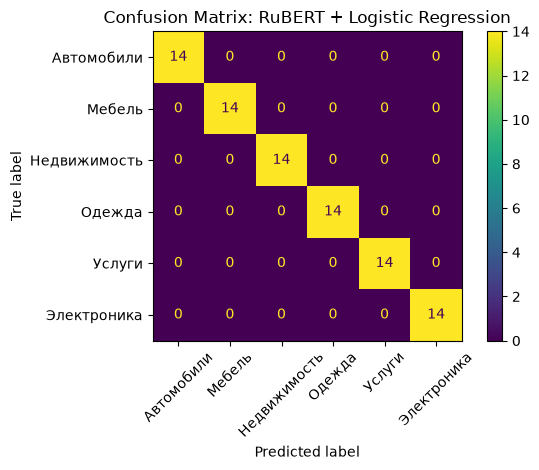

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test_v2,
    y_pred_transformer,
    labels=transformer_classifier.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=transformer_classifier.classes_
)

disp.plot(xticks_rotation=45)

plt.title("Confusion Matrix: RuBERT + Logistic Regression")
plt.tight_layout()
plt.show()

In [28]:
experiment_results_final = pd.DataFrame({
    "Модель": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + биграммы + Logistic Regression",
        "Dataset v2 + TF-IDF + Logistic Regression",
        "Char TF-IDF + Logistic Regression",
        "RuBERT embeddings + Logistic Regression"
    ],
    "Датасет": [
        "Dataset v1",
        "Dataset v1",
        "Dataset v2",
        "Dataset v2",
        "Dataset v2"
    ],
    "Признаки": [
        364,
        1127,
        480,
        9873,
        X_train_embeddings.shape[1]
    ],
    "Accuracy": [
        1.000,
        1.000,
        0.988095,
        0.976190,
        accuracy_transformer
    ]
})

experiment_results_final

,Модель,Датасет,Признаки,Accuracy
0,TF-IDF + Logistic Regression,Dataset v1,364,1.000000
1,TF-IDF + биграммы + Logistic Regression,Dataset v1,1127,1.000000
2,Dataset v2 + TF-IDF + Logistic Regression,Dataset v2,480,0.988095
3,Char TF-IDF + Logistic Regression,Dataset v2,9873,0.976190
4,RuBERT embeddings + Logistic Regression,Dataset v2,312,1.000000


In [29]:
manual_comparison = pd.DataFrame({
    "Объявление": [
        "Кожаный диван",
        "Пуховик"
    ],
    "Правильная категория": [
        "Мебель",
        "Одежда"
    ],
    "TF-IDF v1": [
        "Автомобили",
        "Одежда"
    ],
    "TF-IDF v2": [
        "Мебель",
        "Недвижимость"
    ],
    "RuBERT": [
        "Мебель",
        "Одежда"
    ]
})

manual_comparison

,Объявление,Правильная категория,TF-IDF v1,TF-IDF v2,RuBERT
0,Кожаный диван,Мебель,Автомобили,Мебель,Мебель
1,Пуховик,Одежда,Одежда,Недвижимость,Одежда


In [30]:
hard_examples = [
    "Продам удобный предмет для дома, мягкий и большой",
    "Стильная вещь на зиму, почти новая",
    "Надёжный транспорт для города, один владелец",
    "Устройство для работы и учёбы, хорошее состояние",
    "Помещение рядом с метро, подходит для проживания",
    "Помогу настроить технику и установить программы"
]

In [31]:
hard_embeddings = get_embeddings(
    hard_examples,
    tokenizer,
    transformer_model
)

hard_embeddings = np.array(hard_embeddings)

In [32]:
hard_predictions = transformer_classifier.predict(
    hard_embeddings
)

hard_probabilities = transformer_classifier.predict_proba(
    hard_embeddings
)

In [33]:
for text, prediction, probabilities in zip(
    hard_examples,
    hard_predictions,
    hard_probabilities
):
    confidence = probabilities.max()

    print(f"Объявление: {text}")
    print(f"Предсказание: {prediction}")
    print(f"Уверенность: {confidence:.3f}")
    print("-" * 60)

Объявление: Продам удобный предмет для дома, мягкий и большой
Предсказание: Мебель
Уверенность: 0.775
------------------------------------------------------------
Объявление: Стильная вещь на зиму, почти новая
Предсказание: Одежда
Уверенность: 0.952
------------------------------------------------------------
Объявление: Надёжный транспорт для города, один владелец
Предсказание: Автомобили
Уверенность: 0.833
------------------------------------------------------------
Объявление: Устройство для работы и учёбы, хорошее состояние
Предсказание: Электроника
Уверенность: 0.759
------------------------------------------------------------
Объявление: Помещение рядом с метро, подходит для проживания
Предсказание: Недвижимость
Уверенность: 0.997
------------------------------------------------------------
Объявление: Помогу настроить технику и установить программы
Предсказание: Услуги
Уверенность: 0.996
------------------------------------------------------------


In [34]:
for text, prediction, probabilities in zip(
    hard_examples,
    hard_predictions,
    hard_probabilities
):
    print(f"\n{text}")
    print(f"Предсказание: {prediction}")
    
    for category, probability in sorted(
        zip(transformer_classifier.classes_, probabilities),
        key=lambda x: x[1],
        reverse=True
    ):
        print(f"  {category}: {probability:.3f}")


Продам удобный предмет для дома, мягкий и большой
Предсказание: Мебель
  Мебель: 0.775
  Недвижимость: 0.100
  Электроника: 0.087
  Одежда: 0.034
  Автомобили: 0.002
  Услуги: 0.001

Стильная вещь на зиму, почти новая
Предсказание: Одежда
  Одежда: 0.952
  Автомобили: 0.016
  Электроника: 0.015
  Недвижимость: 0.013
  Мебель: 0.003
  Услуги: 0.000

Надёжный транспорт для города, один владелец
Предсказание: Автомобили
  Автомобили: 0.833
  Недвижимость: 0.147
  Услуги: 0.017
  Одежда: 0.001
  Мебель: 0.001
  Электроника: 0.001

Устройство для работы и учёбы, хорошее состояние
Предсказание: Электроника
  Электроника: 0.759
  Услуги: 0.132
  Недвижимость: 0.072
  Мебель: 0.033
  Автомобили: 0.003
  Одежда: 0.001

Помещение рядом с метро, подходит для проживания
Предсказание: Недвижимость
  Недвижимость: 0.997
  Мебель: 0.003
  Электроника: 0.000
  Автомобили: 0.000
  Одежда: 0.000
  Услуги: 0.000

Помогу настроить технику и установить программы
Предсказание: Услуги
  Услуги: 0.996
  Элек

In [35]:
import pandas as pd

experiment_results_final = pd.DataFrame({
    "Модель": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + биграммы + Logistic Regression",
        "Dataset v2 + TF-IDF + Logistic Regression",
        "Char TF-IDF + Logistic Regression",
        "RuBERT embeddings + Logistic Regression"
    ],
    "Датасет": [
        "Dataset v1",
        "Dataset v1",
        "Dataset v2",
        "Dataset v2",
        "Dataset v2"
    ],
    "Признаки": [
        364,
        1127,
        480,
        9873,
        X_train_embeddings.shape[1]
    ],
    "Accuracy": [
        1.000,
        1.000,
        0.988095,
        0.976190,
        accuracy_transformer
    ]
})

experiment_results_final

,Модель,Датасет,Признаки,Accuracy
0,TF-IDF + Logistic Regression,Dataset v1,364,1.000000
1,TF-IDF + биграммы + Logistic Regression,Dataset v1,1127,1.000000
2,Dataset v2 + TF-IDF + Logistic Regression,Dataset v2,480,0.988095
3,Char TF-IDF + Logistic Regression,Dataset v2,9873,0.976190
4,RuBERT embeddings + Logistic Regression,Dataset v2,312,1.000000


## Сравнение подходов

В ходе экспериментов были протестированы несколько способов представления текста.

На первом этапе использовался классический TF-IDF. Затем были добавлены биграммы и расширен датасет.

Отдельно был протестирован character-level TF-IDF. Этот подход дал более низкий результат на тестовой выборке.

Финальный эксперимент использовал embeddings RuBERT в сочетании с Logistic Regression.

## Error Analysis

Несмотря на высокую Accuracy, классическая TF-IDF-модель допускала ошибки на новых формулировках.

Например:

> Кожаный диван в хорошем состоянии, возможен торг

TF-IDF на исходном датасете определил объявление как `Автомобили`.

После расширения датасета модель стала определять этот пример как `Мебель`.

Другой пример:

> Пуховик. Зимний пуховик, почти не носили

TF-IDF на Dataset v2 определил пример как `Недвижимость`.

Анализ показал, что слова `пуховик`, `зимний` и `носили` отсутствовали в словаре модели. Фактически значимым активным признаком осталось слово `не`.

RuBERT корректно классифицировал оба примера.

## Robustness Test

Дополнительно были проверены несколько вручную составленных объявлений с менее очевидными ключевыми словами.

Например:

- «Продам удобный предмет для дома, мягкий и большой»
- «Стильная вещь на зиму, почти новая»
- «Надёжный транспорт для города, один владелец»
- «Устройство для работы и учёбы, хорошее состояние»

Модель правильно определила категории этих примеров, однако для некоторых менее информативных текстов уверенность была ниже.

Это показывает, что даже при правильном предсказании модель может испытывать неопределённость, если в тексте недостаточно явных признаков категории.

In [36]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_v2,
        y_pred_transformer
    )
)

              precision    recall  f1-score   support

  Автомобили       1.00      1.00      1.00        14
      Мебель       1.00      1.00      1.00        14
Недвижимость       1.00      1.00      1.00        14
      Одежда       1.00      1.00      1.00        14
      Услуги       1.00      1.00      1.00        14
 Электроника       1.00      1.00      1.00        14

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



In [37]:
hard_results = []

for text, prediction, probabilities in zip(
    hard_examples,
    hard_predictions,
    hard_probabilities
):
    max_probability = max(probabilities)

    hard_results.append({
        "Текст": text,
        "Предсказание": prediction,
        "Уверенность": max_probability
    })

hard_results_df = pd.DataFrame(hard_results)

hard_results_df

,Текст,Предсказание,Уверенность
0,"Продам удобный предмет для дома, мягкий и большой",Мебель,0.775485
1,"Стильная вещь на зиму, почти новая",Одежда,0.951732
2,"Надёжный транспорт для города, один владелец",Автомобили,0.833422
3,"Устройство для работы и учёбы, хорошее состояние",Электроника,0.758724
4,"Помещение рядом с метро, подходит для проживания",Недвижимость,0.996907
5,Помогу настроить технику и установить программы,Услуги,0.996192


In [38]:
hard_results_df.sort_values(
    "Уверенность"
)

,Текст,Предсказание,Уверенность
3,"Устройство для работы и учёбы, хорошее состояние",Электроника,0.758724
0,"Продам удобный предмет для дома, мягкий и большой",Мебель,0.775485
2,"Надёжный транспорт для города, один владелец",Автомобили,0.833422
1,"Стильная вещь на зиму, почти новая",Одежда,0.951732
5,Помогу настроить технику и установить программы,Услуги,0.996192
4,"Помещение рядом с метро, подходит для проживания",Недвижимость,0.996907


In [39]:
def predict_listing(text):
    """
    Классифицирует текст объявления с помощью RuBERT + Logistic Regression.
    """

    # Получаем embedding
    embedding = get_embeddings(
        [text],
        tokenizer,
        transformer_model
    )

    embedding = np.array(embedding)

    # Предсказываем категорию
    prediction = transformer_classifier.predict(embedding)[0]

    # Получаем вероятности
    probabilities = transformer_classifier.predict_proba(embedding)[0]

    # Формируем результат
    result = pd.DataFrame({
        "Категория": transformer_classifier.classes_,
        "Вероятность": probabilities
    })

    result = result.sort_values(
        "Вероятность",
        ascending=False
    ).reset_index(drop=True)

    return prediction, result

In [40]:
text = """
Продаю ноутбук Lenovo IdeaPad.
15-дюймовый экран, 16 ГБ оперативной памяти,
SSD 512 ГБ. Подходит для работы и учёбы.
"""

prediction, probabilities = predict_listing(text)

print("Предсказанная категория:", prediction)
print("\nВероятности:")

probabilities

Предсказанная категория: Электроника

Вероятности:


,Категория,Вероятность
0,Электроника,0.996988
1,Мебель,0.001448
2,Услуги,0.001107
3,Недвижимость,0.000299
4,Автомобили,0.000149
5,Одежда,0.000009


In [41]:
text = """
Мягкий большой предмет интерьера для гостиной.
Состояние хорошее, механизм раскладывания работает.
Самовывоз.
"""

prediction, probabilities = predict_listing(text)

print("Предсказанная категория:", prediction)
print("\nВероятности:")

probabilities

Предсказанная категория: Мебель

Вероятности:


,Категория,Вероятность
0,Мебель,0.992455
1,Электроника,0.004847
2,Недвижимость,0.001725
3,Услуги,0.000647
4,Одежда,0.000292
5,Автомобили,0.000034


## Inference

Для демонстрации работы модели создана функция, которая принимает текст нового объявления и возвращает:

- предсказанную категорию;
- вероятности всех категорий.

In [42]:
test_listings = [
    "Продаю Apple MacBook Air, 16 ГБ оперативной памяти, SSD 512 ГБ.",
    "Большой угловой диван для гостиной, раскладывается, состояние хорошее.",
    "Сдаётся светлая двухкомнатная квартира рядом с метро.",
    "Женская куртка на осень, размер M, почти не носили.",
    "Toyota Corolla, автоматическая коробка, один владелец.",
    "Помогу настроить Wi-Fi, установить Windows и необходимые программы."
]

for text in test_listings:
    prediction, probabilities = predict_listing(text)

    confidence = probabilities.iloc[0]["Вероятность"]

    print(f"\nОбъявление: {text}")
    print(f"Категория: {prediction}")
    print(f"Уверенность: {confidence:.3f}")


Объявление: Продаю Apple MacBook Air, 16 ГБ оперативной памяти, SSD 512 ГБ.
Категория: Электроника
Уверенность: 0.999

Объявление: Большой угловой диван для гостиной, раскладывается, состояние хорошее.
Категория: Мебель
Уверенность: 1.000

Объявление: Сдаётся светлая двухкомнатная квартира рядом с метро.
Категория: Недвижимость
Уверенность: 0.999

Объявление: Женская куртка на осень, размер M, почти не носили.
Категория: Одежда
Уверенность: 1.000

Объявление: Toyota Corolla, автоматическая коробка, один владелец.
Категория: Автомобили
Уверенность: 0.996

Объявление: Помогу настроить Wi-Fi, установить Windows и необходимые программы.
Категория: Услуги
Уверенность: 0.825


# Выводы

В ходе проекта была исследована задача автоматической классификации объявлений по тексту.

Были рассмотрены классические и transformer-подходы:

- TF-IDF;
- TF-IDF с биграммами;
- character-level TF-IDF;
- embeddings RuBERT + Logistic Regression.

Расширение датасета позволило исправить отдельные ошибки baseline-модели. Анализ ошибок также показал проблему отсутствующих слов в словаре классического TF-IDF-подхода.

RuBERT корректно классифицировал тестовую выборку и показал Accuracy 1.000 на используемом синтетическом датасете.

При этом результат нельзя напрямую переносить на реальные объявления. Основные ограничения проекта:

- небольшой размер датасета;
- синтетические данные;
- регулярность формулировок;
- отсутствие реальных пользовательских объявлений;
- отсутствие отдельного production-like validation set.

Следующим этапом развития проекта может стать обучение и оценка модели на более крупном и разнообразном наборе реальных или публичных данных, а также добавление confidence threshold для обработки неоднозначных объявлений.